In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [3]:
import glob
import joblib
import pandas as pd
#from pathlib import Path
import matplotlib.pyplot as plt

from phonetics import utils as u
from phonetics import phone_info as ph_i 
from phonetics import plots as plots

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/experiments'
experiment_path = f'{root}/maria_v2_NEW/feat_768d'
feat_path = f'{experiment_path}/feat_768d_layer_12.csv'

In [ ]:
# feat_paths = glob.glob(f'{root}/feat/feat_last/*.csv')
# lab_paths = glob.glob(f'{root}/lab/*.lab')

In [5]:
df_anotated_all = pd.read_csv(feat_path, index_col=0)

<Axes: xlabel='phone_base'>

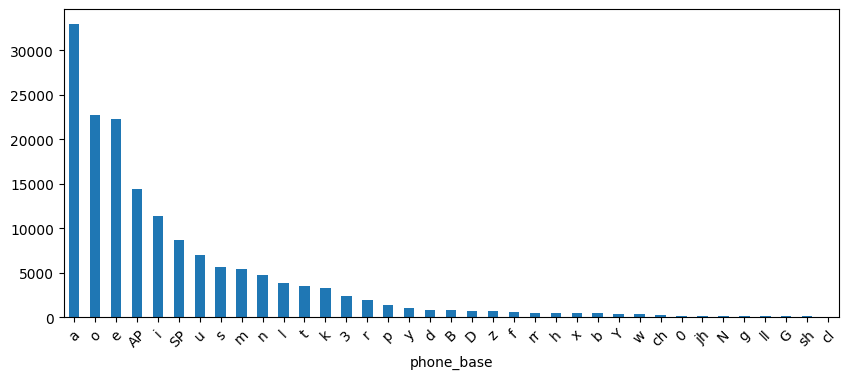

In [6]:
plt.figure(figsize=(10,4))
df_anotated_all['phone_base'].value_counts().plot.bar(rot = 45)

In [7]:
len(df_anotated_all['phone_base'])*0.02/60

53.20033333333333

In [8]:
df_anotated_all['song'].unique()

array(['CA_la_pastoreta', 'ES_tu_que_vienes_a_rondarme', 'CA_impro',
       'ES_milagro', 'CA_sol_solet', 'ES_jota', 'CA_impro2',
       'CA_un_gat_petit_tv3', 'ES_tras_de_ti', 'ES_ventura',
       'CA_sol_solet-2', 'CA_mabravasa', 'CA_no_he_desitjat',
       'ES_quien_me_ama', 'ES_el_dia_que_naci_yo', 'CA_impro3',
       'ES_volver_a_los_17', 'ES_galapaguito', 'ES_hildegart',
       'ES_yo_vi_secarse_una_jara', 'ES_la_sobra_de_la_luz',
       'ES_que_lejos_estoy_de_la_tierra', 'ES_lucero_de_la_maniana',
       'CA_xiqueta_meuna', 'CA_tu_saps', 'ES_negro_infinito', 'CA_viola',
       'CA_sibi_la', 'ES_ventura2', 'CA_meteorit_ferit'], dtype=object)

In [9]:
umap2 = u.train_umap(
        df_anotated_all,
        exclude_phones = ['SP'],
        n_components=2, 
        n_neighbors=100, 
        min_dist=0.1,
        save_model = False,
        folder = None)

Training UMAP with parameters n_components : 2, n_neighbors 100, min_dist : 0.1, n_jobs : -1
Finished umap traning. Training time: 344.40755581855774


In [10]:
df_proj2d = u.make_proj_anotated_feat_df(df_anotated_all, 
                                        umap2,
                                        save_df = False,
                                        folder = None)

Applying dimensional reduction
Reduced to 2 dimensions
Finished computing projection. Transform time :94.23414301872253


In [11]:
unique_phones = [k for k in df_proj2d['phone_base'].value_counts().keys() if k != 'AP']

Making a 2d plot


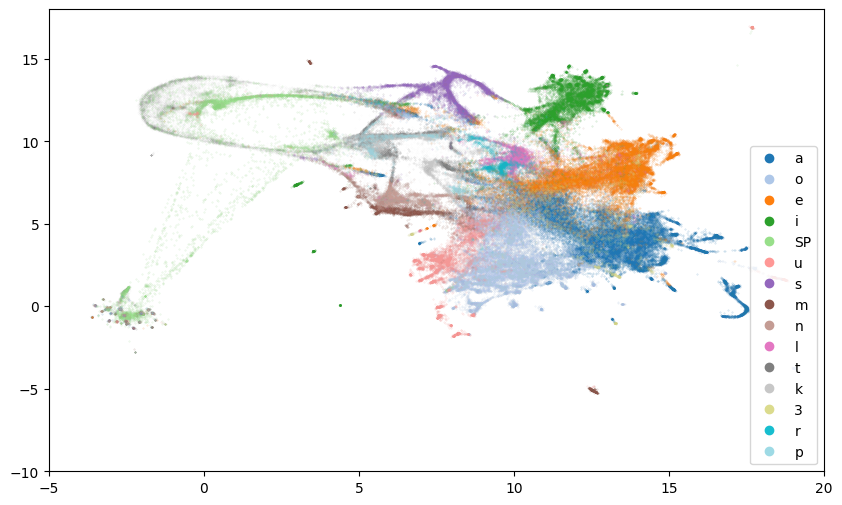

In [12]:
plots.make_tagged_LS_plot(df_proj2d,
            phones = unique_phones[:15],
            alpha = 0.25, 
            s = 0.1,
            show_global=True,
            xlim = [ -5, 20],
            ylim = [-10, 18])

In [24]:
umap3 = u.train_umap(
        df_anotated_all,
        exclude_phones = ['SP'],
        n_components=3, 
        n_neighbors=200, 
        min_dist=0.1,
        save_model = False,
        folder = None)

Training UMAP with parameters n_components : 3, n_neighbors 200, min_dist : 0.1, n_jobs : -1
Finished umap traning. Training time: 532.9422960281372


In [25]:
df_proj3d = u.make_proj_anotated_feat_df(df_anotated_all, 
                                        umap3,
                                        save_df = False,
                                        folder = None)

Applying dimensional reduction
Reduced to 3 dimensions
Finished computing projection. Transform time :168.92993712425232


Making a 3d plot


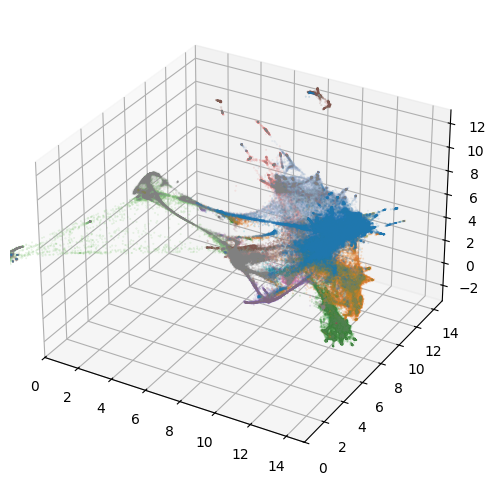

In [23]:
plots.make_tagged_LS_plot(df_proj3d,
            phones = unique_phones[:15],
            alpha = 0.25, 
            s = 0.1,
            show_global=True, 
            add_legend=False,
            xlim=[0,15],
            ylim=[0,15])